## Data Cleaning in Pandas

In [176]:
import pandas as pd

In [177]:
df = pd.read_excel(r"C:\Users\pasum\1.PANDAS LEARNING🔥\Pandas_learning_ALEX_THE_ANALYST\files_and_code\Customer Call List.xlsx")

In [178]:
df.head()

,CustomerID,First_Name,Last_Name,Phone_Number,Address,Paying Customer,Do_Not_Contact,Not_Useful_Column
0,1001,Frodo,Baggins,123-545-5421,"123 Shire Lane, Shire",Yes,No,True
1,1002,Abed,Nadir,123/643/9775,93 West Main Street,No,Yes,False
2,1003,Walter,/White,7066950392,298 Drugs Driveway,N,NaN,True
3,1004,Dwight,Schrute,123-543-2345,"980 Paper Avenue, Pennsylvania, 18503",Yes,Y,True
4,1005,Jon,Snow,876|678|3469,123 Dragons Road,Y,No,True


In [179]:
df.dtypes

CustomerID            int64
First_Name           object
Last_Name            object
Phone_Number         object
Address              object
Paying Customer      object
Do_Not_Contact       object
Not_Useful_Column      bool
dtype: object

In [180]:
df.duplicated()

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20     True
dtype: bool

here in row 20 has duplicate value, so we need to remove

In [181]:
df.drop_duplicates(inplace=True)

In [182]:
df.duplicated()

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
dtype: bool

we successfully remove duplicates

In [183]:
df.head()

,CustomerID,First_Name,Last_Name,Phone_Number,Address,Paying Customer,Do_Not_Contact,Not_Useful_Column
0,1001,Frodo,Baggins,123-545-5421,"123 Shire Lane, Shire",Yes,No,True
1,1002,Abed,Nadir,123/643/9775,93 West Main Street,No,Yes,False
2,1003,Walter,/White,7066950392,298 Drugs Driveway,N,NaN,True
3,1004,Dwight,Schrute,123-543-2345,"980 Paper Avenue, Pennsylvania, 18503",Yes,Y,True
4,1005,Jon,Snow,876|678|3469,123 Dragons Road,Y,No,True


here Not_Useful_Column is useless. so we need to remove it

In [184]:
df.drop(columns='Not_Useful_Column', inplace=True)

In [185]:
df.head()

,CustomerID,First_Name,Last_Name,Phone_Number,Address,Paying Customer,Do_Not_Contact
0,1001,Frodo,Baggins,123-545-5421,"123 Shire Lane, Shire",Yes,No
1,1002,Abed,Nadir,123/643/9775,93 West Main Street,No,Yes
2,1003,Walter,/White,7066950392,298 Drugs Driveway,N,NaN
3,1004,Dwight,Schrute,123-543-2345,"980 Paper Avenue, Pennsylvania, 18503",Yes,Y
4,1005,Jon,Snow,876|678|3469,123 Dragons Road,Y,No


we successfully removed 'Not_Useful_Column'column from the DataFrame

we got the next issue here the Last_Name column is looks bad like '/White' here '/' shouldn't be there in last name of any person right so we need to fix issues like this.

In [186]:
df['Last_Name'] = df['Last_Name'].str.strip('/')
df['Last_Name'] = df['Last_Name'].str.strip('...')
df['Last_Name'] = df['Last_Name'].str.strip('_')
#you can do the above 3 lines with this single line
#df["Last_Name"] = df["Last_Name"].str.strip('/._')
df

,CustomerID,First_Name,Last_Name,Phone_Number,Address,Paying Customer,Do_Not_Contact
0,1001,Frodo,Baggins,123-545-5421,"123 Shire Lane, Shire",Yes,No
1,1002,Abed,Nadir,123/643/9775,93 West Main Street,No,Yes
2,1003,Walter,White,7066950392,298 Drugs Driveway,N,NaN
3,1004,Dwight,Schrute,123-543-2345,"980 Paper Avenue, Pennsylvania, 18503",Yes,Y
4,1005,Jon,Snow,876|678|3469,123 Dragons Road,Y,No
5,1006,Ron,Swanson,304-762-2467,768 City Parkway,Yes,Yes
6,1007,Jeff,Winger,NaN,1209 South Street,No,No
7,1008,Sherlock,Holmes,876|678|3469,98 Clue Drive,N,No
8,1009,Gandalf,NaN,N/a,123 Middle Earth,Yes,NaN
9,1010,Peter,Parker,123-545-5421,"25th Main Street, New York",Yes,No


Now the 'Phone_Number' column is very inconsistent ad irrregular. we need to clean that now

In [187]:
#This is how this looks now
df['Phone_Number']

0     123-545-5421
1     123/643/9775
2       7066950392
3     123-543-2345
4     876|678|3469
5     304-762-2467
6              NaN
7     876|678|3469
8              N/a
9     123-545-5421
10             NaN
11      7066950392
12    123-543-2345
13    876|678|3469
14    304-762-2467
15    123-545-5421
16    123/643/9775
17      7066950392
18             N/a
19    876|678|3469
Name: Phone_Number, dtype: object

In [188]:
df["Phone_Number"] = df["Phone_Number"].str.replace(r'\D', '', regex=True)
df["Phone_Number"]

0     1235455421
1     1236439775
2            NaN
3     1235432345
4     8766783469
5     3047622467
6            NaN
7     8766783469
8               
9     1235455421
10           NaN
11           NaN
12    1235432345
13    8766783469
14    3047622467
15    1235455421
16    1236439775
17           NaN
18              
19    8766783469
Name: Phone_Number, dtype: object

In [189]:
df["Phone_Number"].apply(type) #to see the type of each row because phone_numbers is object type

0       <class 'str'>
1       <class 'str'>
2     <class 'float'>
3       <class 'str'>
4       <class 'str'>
5       <class 'str'>
6     <class 'float'>
7       <class 'str'>
8       <class 'str'>
9       <class 'str'>
10    <class 'float'>
11    <class 'float'>
12      <class 'str'>
13      <class 'str'>
14      <class 'str'>
15      <class 'str'>
16      <class 'str'>
17    <class 'float'>
18      <class 'str'>
19      <class 'str'>
Name: Phone_Number, dtype: object

In [190]:
df["Phone_Number"] = df["Phone_Number"].str.replace(
    r'(\d{3})(\d{3})(\d{4})',
    r'\1-\2-\3',
    regex=True
)
df["Phone_Number"] #we added '-' to the phone number for the convention

0     123-545-5421
1     123-643-9775
2              NaN
3     123-543-2345
4     876-678-3469
5     304-762-2467
6              NaN
7     876-678-3469
8                 
9     123-545-5421
10             NaN
11             NaN
12    123-543-2345
13    876-678-3469
14    304-762-2467
15    123-545-5421
16    123-643-9775
17             NaN
18                
19    876-678-3469
Name: Phone_Number, dtype: object

### The next thing we gonna look at is address column

#### The address column looks bad and also because each address row does not follow any structure. so we need to handle it

so the address contains here is street address, state and a zipcode, so Idea is create columns ['street_address','state','zip_code']

In [191]:
#Take look at address column
df['Address']

0                     123 Shire Lane, Shire
1                       93 West Main Street
2                        298 Drugs Driveway
3     980 Paper Avenue, Pennsylvania, 18503
4                          123 Dragons Road
5                          768 City Parkway
6                         1209 South Street
7                             98 Clue Drive
8                          123 Middle Earth
9                25th Main Street, New York
10                    612 Shire Lane, Shire
11                     2394 Hogwarts Avenue
12                         2039 Main Street
13                         343 City Parkway
14                            214 HR Avenue
15                     2395 Hogwarts Avenue
16           121 Paper Avenue, Pennsylvania
17                          3498 Super Lane
18                                      N/a
19              910 Tatooine Road, Tatooine
Name: Address, dtype: object

In [192]:
df["Address"].str.split(',', n=2, expand=True)

,0,1,2
0,123 Shire Lane,Shire,None
1,93 West Main Street,None,None
2,298 Drugs Driveway,None,None
3,980 Paper Avenue,Pennsylvania,18503
4,123 Dragons Road,None,None
5,768 City Parkway,None,None
6,1209 South Street,None,None
7,98 Clue Drive,None,None
8,123 Middle Earth,None,None
9,25th Main Street,New York,None


In [193]:
help('str.split')

Help on method_descriptor in str:

str.split = split(self, /, sep=None, maxsplit=-1) unbound builtins.str method
    Return a list of the substrings in the string, using sep as the separator string.

      sep
        The separator used to split the string.

        When set to None (the default value), will split on any whitespace
        character (including \n \r \t \f and spaces) and will discard
        empty strings from the result.
      maxsplit
        Maximum number of splits.
        -1 (the default value) means no limit.

    Splitting starts at the front of the string and works to the end.

    Note, str.split() is mainly useful for data that has been intentionally
    delimited.  With natural text that includes punctuation, consider using
    the regular expression module.



In [194]:
df[['street_address','state','zip_code']] = df["Address"].str.split(',', n=2, expand=True)

In [195]:
df.head()

,CustomerID,First_Name,Last_Name,Phone_Number,Address,Paying Customer,Do_Not_Contact,street_address,state,zip_code
0,1001,Frodo,Baggins,123-545-5421,"123 Shire Lane, Shire",Yes,No,123 Shire Lane,Shire,None
1,1002,Abed,Nadir,123-643-9775,93 West Main Street,No,Yes,93 West Main Street,None,None
2,1003,Walter,White,NaN,298 Drugs Driveway,N,NaN,298 Drugs Driveway,None,None
3,1004,Dwight,Schrute,123-543-2345,"980 Paper Avenue, Pennsylvania, 18503",Yes,Y,980 Paper Avenue,Pennsylvania,18503
4,1005,Jon,Snow,876-678-3469,123 Dragons Road,Y,No,123 Dragons Road,None,None


we split the address into 3 columns no 'Address' column is no more needed so drop it

In [196]:
df.drop(columns = 'Address',inplace=True)
df

,CustomerID,First_Name,Last_Name,Phone_Number,Paying Customer,Do_Not_Contact,street_address,state,zip_code
0,1001,Frodo,Baggins,123-545-5421,Yes,No,123 Shire Lane,Shire,None
1,1002,Abed,Nadir,123-643-9775,No,Yes,93 West Main Street,None,None
2,1003,Walter,White,NaN,N,NaN,298 Drugs Driveway,None,None
3,1004,Dwight,Schrute,123-543-2345,Yes,Y,980 Paper Avenue,Pennsylvania,18503
4,1005,Jon,Snow,876-678-3469,Y,No,123 Dragons Road,None,None
5,1006,Ron,Swanson,304-762-2467,Yes,Yes,768 City Parkway,None,None
6,1007,Jeff,Winger,NaN,No,No,1209 South Street,None,None
7,1008,Sherlock,Holmes,876-678-3469,N,No,98 Clue Drive,None,None
8,1009,Gandalf,NaN,,Yes,NaN,123 Middle Earth,None,None
9,1010,Peter,Parker,123-545-5421,Yes,No,25th Main Street,New York,None


The column 'Paying Customer' and 'Do_Not_Contact' has Yes or No that ok. but Y and N are not ok right we need to have either yes or no. Now cleanly format Y to Yes and N to NO

In [197]:
df['Paying Customer'] = df['Paying Customer'].replace('Y','Yes')

In [198]:
df['Paying Customer'] = df['Paying Customer'].replace('N','No')

In [199]:
df['Paying Customer']

0     Yes
1      No
2      No
3     Yes
4     Yes
5     Yes
6      No
7      No
8     Yes
9     Yes
10    Yes
11    Yes
12    Yes
13    Yes
14     No
15     No
16    Yes
17    Yes
18    N/a
19    Yes
Name: Paying Customer, dtype: object

I have correctly formatted the Paying Customer column now I will follow the same process for this column also 'Do_Not_Contact'

In [200]:
#have a look at this column 'Do_Not_Contact'
df['Do_Not_Contact']

0      No
1     Yes
2     NaN
3       Y
4      No
5     Yes
6      No
7      No
8     NaN
9      No
10     No
11    NaN
12      N
13     No
14     No
15      N
16     No
17    NaN
18    Yes
19      N
Name: Do_Not_Contact, dtype: object

In [201]:
df['Do_Not_Contact'].replace({'Y':'Yes', 'N':'No'},inplace=True)
df['Do_Not_Contact']

0      No
1     Yes
2     NaN
3     Yes
4      No
5     Yes
6      No
7      No
8     NaN
9      No
10     No
11    NaN
12     No
13     No
14     No
15     No
16     No
17    NaN
18    Yes
19     No
Name: Do_Not_Contact, dtype: object

Now have look at whole table

In [202]:
df

,CustomerID,First_Name,Last_Name,Phone_Number,Paying Customer,Do_Not_Contact,street_address,state,zip_code
0,1001,Frodo,Baggins,123-545-5421,Yes,No,123 Shire Lane,Shire,None
1,1002,Abed,Nadir,123-643-9775,No,Yes,93 West Main Street,None,None
2,1003,Walter,White,NaN,No,NaN,298 Drugs Driveway,None,None
3,1004,Dwight,Schrute,123-543-2345,Yes,Yes,980 Paper Avenue,Pennsylvania,18503
4,1005,Jon,Snow,876-678-3469,Yes,No,123 Dragons Road,None,None
5,1006,Ron,Swanson,304-762-2467,Yes,Yes,768 City Parkway,None,None
6,1007,Jeff,Winger,NaN,No,No,1209 South Street,None,None
7,1008,Sherlock,Holmes,876-678-3469,No,No,98 Clue Drive,None,None
8,1009,Gandalf,NaN,,Yes,NaN,123 Middle Earth,None,None
9,1010,Peter,Parker,123-545-5421,Yes,No,25th Main Street,New York,None


Now let's get rid of NaN and N/A using fillna which will remove null values.

In [203]:
df.fillna('',inplace=True)
df.replace('N/a','',inplace=True)

In [204]:
df

,CustomerID,First_Name,Last_Name,Phone_Number,Paying Customer,Do_Not_Contact,street_address,state,zip_code
0,1001,Frodo,Baggins,123-545-5421,Yes,No,123 Shire Lane,Shire,
1,1002,Abed,Nadir,123-643-9775,No,Yes,93 West Main Street,,
2,1003,Walter,White,,No,,298 Drugs Driveway,,
3,1004,Dwight,Schrute,123-543-2345,Yes,Yes,980 Paper Avenue,Pennsylvania,18503
4,1005,Jon,Snow,876-678-3469,Yes,No,123 Dragons Road,,
5,1006,Ron,Swanson,304-762-2467,Yes,Yes,768 City Parkway,,
6,1007,Jeff,Winger,,No,No,1209 South Street,,
7,1008,Sherlock,Holmes,876-678-3469,No,No,98 Clue Drive,,
8,1009,Gandalf,,,Yes,,123 Middle Earth,,
9,1010,Peter,Parker,123-545-5421,Yes,No,25th Main Street,New York,


ok, assume I need to give this data to call center. This column 'Do_Not_Contact' has customer consent. if Do_Not_Contact is Yes we need to remove that record, and also if phone number is messing then also remove that row because it doesn't make any sense by give that data. ok let's work on that

First I will remove no phone number records

while doing operations like this always test before applying on real data. in my case real data is df and backup is temp

In [205]:
temp = df.copy()

In [206]:
temp['Phone_Number'].apply(type)

0     <class 'str'>
1     <class 'str'>
2     <class 'str'>
3     <class 'str'>
4     <class 'str'>
5     <class 'str'>
6     <class 'str'>
7     <class 'str'>
8     <class 'str'>
9     <class 'str'>
10    <class 'str'>
11    <class 'str'>
12    <class 'str'>
13    <class 'str'>
14    <class 'str'>
15    <class 'str'>
16    <class 'str'>
17    <class 'str'>
18    <class 'str'>
19    <class 'str'>
Name: Phone_Number, dtype: object

In [207]:
for i in temp.index:
    if temp.loc[i,'Phone_Number'] == '':
        temp.drop(i,inplace=True)
for i in temp.index: #removing rows where Do_Not_Contact is Yes
    if temp.loc[i,'Do_Not_Contact'] == 'Yes':
        temp.drop(i,inplace=True)

temp

,CustomerID,First_Name,Last_Name,Phone_Number,Paying Customer,Do_Not_Contact,street_address,state,zip_code
0,1001,Frodo,Baggins,123-545-5421,Yes,No,123 Shire Lane,Shire,
4,1005,Jon,Snow,876-678-3469,Yes,No,123 Dragons Road,,
7,1008,Sherlock,Holmes,876-678-3469,No,No,98 Clue Drive,,
9,1010,Peter,Parker,123-545-5421,Yes,No,25th Main Street,New York,
12,1013,Don,Draper,123-543-2345,Yes,No,2039 Main Street,,
13,1014,Leslie,Knope,876-678-3469,Yes,No,343 City Parkway,,
14,1015,Toby,Flenderson,304-762-2467,No,No,214 HR Avenue,,
15,1016,Ron,Weasley,123-545-5421,No,No,2395 Hogwarts Avenue,,
16,1017,Michael,Scott,123-643-9775,Yes,No,121 Paper Avenue,Pennsylvania,
19,1020,Anakin,Skywalker,876-678-3469,Yes,No,910 Tatooine Road,Tatooine,


Now I will apply the same operations to my real data, as I did with my temporary data.

In [208]:
for i in df.index:
    if df.loc[i,'Phone_Number'] == '':
        df.drop(i,inplace=True)

df

,CustomerID,First_Name,Last_Name,Phone_Number,Paying Customer,Do_Not_Contact,street_address,state,zip_code
0,1001,Frodo,Baggins,123-545-5421,Yes,No,123 Shire Lane,Shire,
1,1002,Abed,Nadir,123-643-9775,No,Yes,93 West Main Street,,
3,1004,Dwight,Schrute,123-543-2345,Yes,Yes,980 Paper Avenue,Pennsylvania,18503
4,1005,Jon,Snow,876-678-3469,Yes,No,123 Dragons Road,,
5,1006,Ron,Swanson,304-762-2467,Yes,Yes,768 City Parkway,,
7,1008,Sherlock,Holmes,876-678-3469,No,No,98 Clue Drive,,
9,1010,Peter,Parker,123-545-5421,Yes,No,25th Main Street,New York,
12,1013,Don,Draper,123-543-2345,Yes,No,2039 Main Street,,
13,1014,Leslie,Knope,876-678-3469,Yes,No,343 City Parkway,,
14,1015,Toby,Flenderson,304-762-2467,No,No,214 HR Avenue,,


You can observe that some indices are missing after removing unwanted data, so we need to reset them correctly.

In [209]:
temp.reset_index() #If you are not familiar with a new function, remember to test on temp data before trying it on real data.
#observe it created a new index and adding previous index as a new property(column) we do not want that.

,index,CustomerID,First_Name,Last_Name,Phone_Number,Paying Customer,Do_Not_Contact,street_address,state,zip_code
0,0,1001,Frodo,Baggins,123-545-5421,Yes,No,123 Shire Lane,Shire,
1,4,1005,Jon,Snow,876-678-3469,Yes,No,123 Dragons Road,,
2,7,1008,Sherlock,Holmes,876-678-3469,No,No,98 Clue Drive,,
3,9,1010,Peter,Parker,123-545-5421,Yes,No,25th Main Street,New York,
4,12,1013,Don,Draper,123-543-2345,Yes,No,2039 Main Street,,
5,13,1014,Leslie,Knope,876-678-3469,Yes,No,343 City Parkway,,
6,14,1015,Toby,Flenderson,304-762-2467,No,No,214 HR Avenue,,
7,15,1016,Ron,Weasley,123-545-5421,No,No,2395 Hogwarts Avenue,,
8,16,1017,Michael,Scott,123-643-9775,Yes,No,121 Paper Avenue,Pennsylvania,
9,19,1020,Anakin,Skywalker,876-678-3469,Yes,No,910 Tatooine Road,Tatooine,


this will reset the index and remove the previous index: temp.reset_index(drop=True)

In [210]:
temp.reset_index(drop=True)

,CustomerID,First_Name,Last_Name,Phone_Number,Paying Customer,Do_Not_Contact,street_address,state,zip_code
0,1001,Frodo,Baggins,123-545-5421,Yes,No,123 Shire Lane,Shire,
1,1005,Jon,Snow,876-678-3469,Yes,No,123 Dragons Road,,
2,1008,Sherlock,Holmes,876-678-3469,No,No,98 Clue Drive,,
3,1010,Peter,Parker,123-545-5421,Yes,No,25th Main Street,New York,
4,1013,Don,Draper,123-543-2345,Yes,No,2039 Main Street,,
5,1014,Leslie,Knope,876-678-3469,Yes,No,343 City Parkway,,
6,1015,Toby,Flenderson,304-762-2467,No,No,214 HR Avenue,,
7,1016,Ron,Weasley,123-545-5421,No,No,2395 Hogwarts Avenue,,
8,1017,Michael,Scott,123-643-9775,Yes,No,121 Paper Avenue,Pennsylvania,
9,1020,Anakin,Skywalker,876-678-3469,Yes,No,910 Tatooine Road,Tatooine,


In [211]:
df.reset_index(drop=True)

,CustomerID,First_Name,Last_Name,Phone_Number,Paying Customer,Do_Not_Contact,street_address,state,zip_code
0,1001,Frodo,Baggins,123-545-5421,Yes,No,123 Shire Lane,Shire,
1,1002,Abed,Nadir,123-643-9775,No,Yes,93 West Main Street,,
2,1004,Dwight,Schrute,123-543-2345,Yes,Yes,980 Paper Avenue,Pennsylvania,18503
3,1005,Jon,Snow,876-678-3469,Yes,No,123 Dragons Road,,
4,1006,Ron,Swanson,304-762-2467,Yes,Yes,768 City Parkway,,
5,1008,Sherlock,Holmes,876-678-3469,No,No,98 Clue Drive,,
6,1010,Peter,Parker,123-545-5421,Yes,No,25th Main Street,New York,
7,1013,Don,Draper,123-543-2345,Yes,No,2039 Main Street,,
8,1014,Leslie,Knope,876-678-3469,Yes,No,343 City Parkway,,
9,1015,Toby,Flenderson,304-762-2467,No,No,214 HR Avenue,,


To improve the business we need to respect Paying customers

In [212]:
for i in temp.index:
    if temp.loc[i,'Paying Customer']=='No':
        temp.drop(i,inplace=True)
temp

,CustomerID,First_Name,Last_Name,Phone_Number,Paying Customer,Do_Not_Contact,street_address,state,zip_code
0,1001,Frodo,Baggins,123-545-5421,Yes,No,123 Shire Lane,Shire,
4,1005,Jon,Snow,876-678-3469,Yes,No,123 Dragons Road,,
9,1010,Peter,Parker,123-545-5421,Yes,No,25th Main Street,New York,
12,1013,Don,Draper,123-543-2345,Yes,No,2039 Main Street,,
13,1014,Leslie,Knope,876-678-3469,Yes,No,343 City Parkway,,
16,1017,Michael,Scott,123-643-9775,Yes,No,121 Paper Avenue,Pennsylvania,
19,1020,Anakin,Skywalker,876-678-3469,Yes,No,910 Tatooine Road,Tatooine,


### That’s it. I have cleaned the data. Now I can provide it to the call center as required, and I can also pass this data to the visualization team for further analysis.

In [213]:
df.to_excel('Customer_Data_Preparation_for_Targeted_Outreach.xlsx')

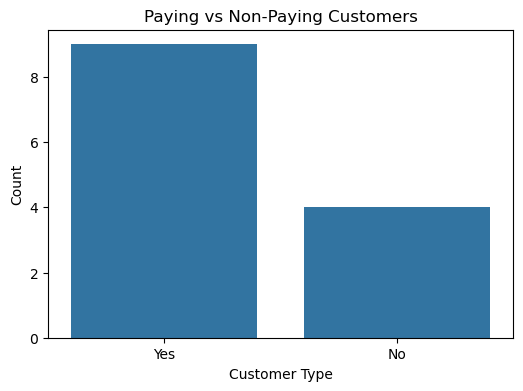

<Figure size 640x480 with 0 Axes>

In [220]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Paying Customer')
plt.title("Paying vs Non-Paying Customers")
plt.xlabel("Customer Type")
plt.ylabel("Count")
plt.show()
plt.savefig('Paying vs Non-Paying Customers (Revenue Potential).png')

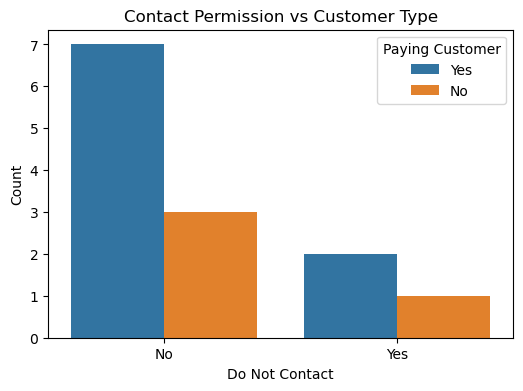

<Figure size 640x480 with 0 Axes>

In [219]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Do_Not_Contact', hue='Paying Customer')
plt.title("Contact Permission vs Customer Type")
plt.xlabel("Do Not Contact")
plt.ylabel("Count")
plt.show()
plt.savefig('Contactability Analysis (Reachable vs Not Reachable).png')

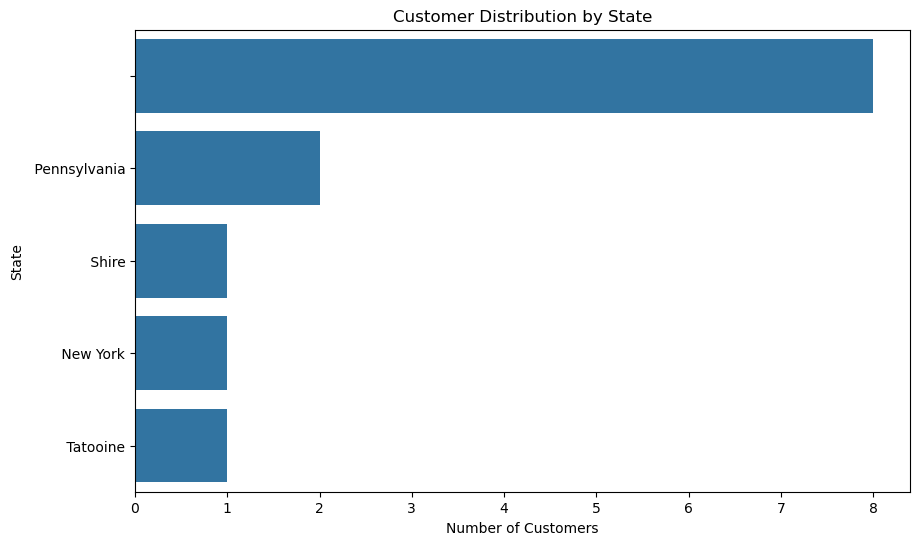

<Figure size 640x480 with 0 Axes>

In [218]:
plt.figure(figsize=(10,6))
state_counts = df['state'].value_counts()

sns.barplot(x=state_counts.values, y=state_counts.index)
plt.title("Customer Distribution by State")
plt.xlabel("Number of Customers")
plt.ylabel("State")
plt.show()
plt.savefig('Customer Distribution by State (Geographic Strategy).png')